<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="page-break-after: always;"></div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation du sous-module pyplot de matplotlib
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.3 - Création fonction pour avoir des informations sur les données brutes</h3>
</div>

In [3]:
# Construisons une fonction permettant d'avoir des infos générales sur un tableau donné.
def generate_stats(dataframe, dataframe_title):

    """
Utilité: Génère un tableau récapitulant les informations statistiques principales d'une table donnée.

Arg:
- dataframe: Nom de la variable contenant la table au format pandas dataframe.
- dataframe_title (string): Nom du tableau à spécifier entre " " (à choisir, peut être différent du nom du fichier)
    """
    # Création du tableau des infos par défaut
    dfDescribe = dataframe.describe(include = 'all')

    # Création info sur les dtypes de chaque colonne et stockage dans un tableau df_dType
    df_dType = (pd.DataFrame(dataframe.dtypes, columns=["dType"])).T

    # Option : ajout info de la fréquence en pourcentage, dans le cas où il y a des variables qualitatives
    if "freq" in dfDescribe.index:
        freqPourcent = ((dfDescribe.loc["freq"]*100/len(dataframe)).apply(pd.to_numeric, errors = "coerce")).round(1)
        df_freqPourcent = pd.DataFrame(freqPourcent).T
        df_freqPourcent = df_freqPourcent.rename(index={"freq": "freq%"}, inplace=False)

        # Insertion de la ligne df_freqPourcent entre les lignes freq et mean de dfDescribe, dans le cas où il existe des variables quantitatives
        if "mean" in dfDescribe.index:
            dfDescribeHaut = dfDescribe.loc[:"freq"]
            dfDescribeBas = dfDescribe.loc["mean":]
            dfDescribe = pd.concat([dfDescribeHaut, df_freqPourcent, dfDescribeBas], axis=0)
        # Insertion de la ligne df_freqpourcent à la fin du tableau (=> naturellement, après freq), dans le cas où il n'existe pas de variable quantitative
        else:
            dfDescribe = pd.concat([dfDescribe, df_freqPourcent], axis=0)

    # Création info sur le nombre de valeurs manquantes naCount dans chaque colonne (+ pourcentage) et stockage dans un tableau
    MissingValuesCount = dataframe.isnull().sum()
    dfMissingValues = (pd.DataFrame(MissingValuesCount, columns = ["naCount"])).T

    # Option: ajout du pourcentage de valeurs manquantes, dans le cas où il existe des valeurs manquantes
    if dfMissingValues.loc["naCount"].sum() != 0:
        dfMissingValues.loc["naCount%"] = (dfMissingValues.loc["naCount"]*100/len(dataframe)).round(1)

    # Concaténation des tableaux dtype et valeurs manquantes avec le tableau des infos générales
    dataSummary = pd.concat([df_dType, dfMissingValues, dfDescribe], axis=0)

    # Transposons pour plus de lisibilité
    dataSummary = dataSummary.T

    # Trier le tableau par dType
    dataSummary_sort = (dataSummary).sort_values(by="dType")

    # Affichage du tableau infos générales
    print("---Infos générales sur les données du tableau:", dataframe_title, "---")
    print("Dimensions du tableau (nombre de lignes, nombre de colonnes):", dataframe.shape)
    display(dataSummary_sort)

    # Nombre de lignes en doublons + affichage des lignes en doublon si existent
    nombre_doublons = dataframe.duplicated().sum()
    print(f"Nombre de doublon(s) présent(s) : {nombre_doublons}")
    if nombre_doublons>0 :
        lignes_doublons = dataframe[dataframe.duplicated()]
        print(lignes_doublons)
    print("-----")

<div style="page-break-after: always;"></div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [4]:
#Infos générales sur le fichier population
generate_stats(population, "population (brut)")
display(population)

---Infos générales sur les données du tableau: population (brut) ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1416, 3)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,1416.0,NaN,NaN,NaN,NaN,2015.5,1.708428,2013.0,2014.0,2015.5,2017.0,2018.0
Valeur,float64,0,1416.0,NaN,NaN,NaN,NaN,31447.929428,130081.182581,0.793,378.341,5126.48,19306.66275,1427647.786
Zone,object,0,1416,236,Afghanistan,6,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113
...,...,...,...
1411,Zimbabwe,2014,13586.707
1412,Zimbabwe,2015,13814.629
1413,Zimbabwe,2016,14030.331
1414,Zimbabwe,2017,14236.595


<div style="page-break-after: always;"></div>

In [5]:
# Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000-
print("---Table Population, colonne Valeur : AVANT changement d'unité---")
display(population[["Valeur"]].head())

population["Valeur"] = population["Valeur"]*1000

print("---Table Population, colonne Valeur : APRES changement d'unité---")
display(population[["Valeur"]].head())

---Table Population, colonne Valeur : AVANT changement d'unité---


,Valeur
0,32269.589
1,33370.794
2,34413.603
3,35383.032
4,36296.113


---Table Population, colonne Valeur : APRES changement d'unité---


,Valeur
0,32269589.0
1,33370794.0
2,34413603.0
3,35383032.0
4,36296113.0


In [6]:
#Changement du nom de la colonne Valeur par Population
print("Liste des colonnes AVANT renommage : ", list(population.columns))
population = population.rename(columns={"Valeur":"Population"})
print("Liste des colonnes APRES renommage : ", list(population.columns))

Liste des colonnes AVANT renommage :  ['Zone', 'Année', 'Valeur']
Liste des colonnes APRES renommage :  ['Zone', 'Année', 'Population']


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [7]:
#Informations sur le dataset dispo_alimentaire
generate_stats(dispo_alimentaire,"dispo_alimentaire (brut)")
display(dispo_alimentaire)

---Infos générales sur les données du tableau: dispo_alimentaire (brut) ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (15605, 18)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Disponibilité de protéines en quantité (g/personne/jour),float64,4044.0,25.9,11561.0,NaN,NaN,NaN,NaN,1.223608,3.598686,-0.37,0.01,0.1,0.66,54.97
Semences,float64,13514.0,86.6,2091.0,NaN,NaN,NaN,NaN,73.974653,528.069224,0.0,0.0,2.0,17.0,17060.0
Production,float64,6425.0,41.2,9180.0,NaN,NaN,NaN,NaN,1090.379085,12067.344094,0.0,2.0,22.0,191.25,739267.0
Pertes,float64,11327.0,72.6,4278.0,NaN,NaN,NaN,NaN,106.053763,1113.100416,0.0,0.0,4.0,26.0,55047.0
Nourriture,float64,1590.0,10.2,14015.0,NaN,NaN,NaN,NaN,347.931359,4475.704458,-246.0,0.0,5.0,52.0,426850.0
Importations - Quantité,float64,753.0,4.8,14852.0,NaN,NaN,NaN,NaN,87.264543,717.372714,-201.0,0.0,2.0,18.0,63381.0
Exportations - Quantité,float64,3379.0,21.7,12226.0,NaN,NaN,NaN,NaN,110.596925,1053.31899,-41.0,0.0,0.0,9.0,42797.0
Disponibilité intérieure,float64,223.0,1.4,15382.0,NaN,NaN,NaN,NaN,640.29346,9067.267153,-3430.0,0.0,7.0,76.75,739267.0
Variation de stock,float64,8829.0,56.6,6776.0,NaN,NaN,NaN,NaN,-15.407615,549.83454,-39863.0,0.0,0.0,0.0,5284.0
Disponibilité de matière grasse en quantité (g/personne/jour),float64,3811.0,24.4,11794.0,NaN,NaN,NaN,NaN,1.283111,3.680399,-0.03,0.01,0.08,0.63,60.76


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,NaN,NaN,45.0,4.70,4.28,1.41,3.0,NaN,0.0,3.0,NaN,2.0,NaN,NaN,NaN
15601,Îles Salomon,Viande de Volailles,animale,NaN,NaN,11.0,3.34,0.69,1.14,2.0,NaN,2.0,2.0,NaN,0.0,NaN,NaN,NaN
15602,Îles Salomon,"Viande, Autre",animale,NaN,NaN,0.0,0.06,NaN,0.04,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
15603,Îles Salomon,Vin,vegetale,NaN,NaN,0.0,0.07,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


<div style="page-break-after: always;"></div>

In [8]:
# Remplacement des NaN dans le dataset entier par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)
new_naCount = dispo_alimentaire.isnull().sum().sum() #vérification: calcul des valeurs manquantes
print("Nombre de valeur(s) manquante(s) après remplacement:", new_naCount)
print("--- 5 premières lignes de la table suite à remplacement valeurs manquantes par 0---")
display(dispo_alimentaire.head())

Nombre de valeur(s) manquante(s) après remplacement: 0
--- 5 premières lignes de la table suite à remplacement valeurs manquantes par 0---


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Multiplication de toutes les lignes contenant des milliers de tonnes en Kg
for col in ["Aliments pour animaux",
            "Autres Utilisations",
            "Disponibilité intérieure",
            "Exportations - Quantité",
            "Importations - Quantité",
            "Nourriture",
            "Pertes",
            "Production",
            "Semences",
            "Traitement",
            "Variation de stock"]:
       dispo_alimentaire[col] = dispo_alimentaire[col]*1000000
print("---5 premières de lignes de la table, suite à multiplication de toutes les lignes contenant des milliers de tonnes en Kg---")
display(dispo_alimentaire.head())

---5 premières de lignes de la table, suite à multiplication de toutes les lignes contenant des milliers de tonnes en Kg---


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [10]:
#Informations sur le dataset aide_alimentaire
generate_stats(aide_alimentaire, "aide_alimentaire (brut)")
display(aide_alimentaire)

---Infos générales sur les données du tableau: aide_alimentaire (brut) ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1475, 4)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,1475.0,NaN,NaN,NaN,NaN,2014.054237,0.946916,2013.0,2013.0,2014.0,2015.0,2016.0
Valeur,int64,0,1475.0,NaN,NaN,NaN,NaN,7481.96678,23339.531424,0.0,287.5,1178.0,4334.5,265013.0
Pays bénéficiaire,object,0,1475,76,Algérie,39,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Produit,object,0,1475,16,Non-céréales,220,14.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,96
1471,Zimbabwe,2013,Non-céréales,5022
1472,Zimbabwe,2014,Non-céréales,2310
1473,Zimbabwe,2015,Non-céréales,306


<div style="page-break-after: always;"></div>

In [11]:
# Renommage la colonne Pays bénéficiaire par Zone, dans le dataset aide_alimentaire
print(f"Liste des colonnes AVANT renommage : {list(aide_alimentaire.columns)}")
aide_alimentaire = aide_alimentaire.rename(columns={"Pays bénéficiaire":"Zone"})
print("Liste des colonnes APRES renommage:", list(aide_alimentaire.columns))

Liste des colonnes AVANT renommage : ['Pays bénéficiaire', 'Année', 'Produit', 'Valeur']
Liste des colonnes APRES renommage: ['Zone', 'Année', 'Produit', 'Valeur']


In [12]:
# Multiplication de la colonne qui contient des tonnes par 1000 pour avoir des kg, dans le dataset aide_alimentaire
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"]*1000 #multiplication
aide_alimentaire = aide_alimentaire.rename(columns={"Valeur":"Valeur(kg)"}) # Renommage de la colonne pour préciser qu'on a des kg
print("Affichage des 5 premières lignes de la table suite à multiplication de la colonne Valeur qui contient des tonnes par 1000 pour avoir des kg + renommage colonne valeur")
display(aide_alimentaire.head()) #Affichage des 5 premières lignes de la table

Affichage des 5 premières lignes de la table suite à multiplication de la colonne Valeur qui contient des tonnes par 1000 pour avoir des kg + renommage colonne valeur


,Zone,Année,Produit,Valeur(kg)
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [13]:
#Infos sur le dataset sous-nutrition
generate_stats(sous_nutrition,"sous_nutrition (brut)")
display(sous_nutrition)

---Infos générales sur les données du tableau: sous_nutrition (brut) ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1218, 3)


,dType,naCount,naCount%,count,unique,top,freq,freq%
Zone,object,0.0,0.0,1218,203,Afghanistan,6,0.5
Année,object,0.0,0.0,1218,6,2012-2014,203,16.7
Valeur,object,594.0,48.8,624,139,<0.1,120,9.9


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5
...,...,...,...
1213,Zimbabwe,2013-2015,NaN
1214,Zimbabwe,2014-2016,NaN
1215,Zimbabwe,2015-2017,NaN
1216,Zimbabwe,2016-2018,NaN


<div style="page-break-after: always;"></div>

In [14]:
#Nombre de zones qui ont des valeurs NaN dans le dataset sous_nutrition
condition = pd.isna(sous_nutrition["Valeur"]) # Mise en place de la conditon : Valeur doit être NaN
sous_nutrition_NaN = sous_nutrition[condition] # Tableau avec la condition que Valeur = NaN
nb_zone_nan = sous_nutrition_NaN["Zone"].nunique() # Liste des valeurs uniques de la colonne Zone
print("---Nombre de zone(s) où les valeurs sont manquantes---")
print(nb_zone_nan)

---Nombre de zone(s) où les valeurs sont manquantes---
101


In [15]:
#Conversion de la colonne Valeur en numérique, du dataset sous-nutrition
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce") #Conversion en numérique
sous_nutrition["Valeur"] = sous_nutrition["Valeur"].fillna(0) #Remplacement des valeurs manquantes par 0
generate_stats(sous_nutrition,"sous_nutrition, valeurs manquantes nettoyées") #affichage des stats suite à suppression NaN

---Infos générales sur les données du tableau: sous_nutrition, valeurs manquantes nettoyées ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1218, 3)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Valeur,float64,0,1218.0,NaN,NaN,NaN,NaN,2.614778,14.148811,0.0,0.0,0.0,1.2,203.8
Zone,object,0,1218,203,Afghanistan,6,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Année,object,0,1218,6,2012-2014,203,16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


In [16]:
#Renommage de la colonne Valeur par sous_nutrition, dans le dataset sous-nutrition
print(f"Liste des colonnes AVANT renommage : {list(sous_nutrition.columns)}")
sous_nutrition = sous_nutrition.rename(columns={"Valeur":"sous_nutrition"})
print("Liste des colonnes APRES renommage :", list(sous_nutrition.columns))

Liste des colonnes AVANT renommage : ['Zone', 'Année', 'Valeur']
Liste des colonnes APRES renommage : ['Zone', 'Année', 'sous_nutrition']


In [17]:
#Multiplication de la colonne sous_nutrition par 1000000 pour avoir le nombre exact de personnes sous-nutries
sous_nutrition["sous_nutrition"] = sous_nutrition["sous_nutrition"]*1000000 #multiplication
print("---5 premières lignes de la table suite à ajustement unités pour avoir le nombre exact de personnes sous-nutries---")
display(sous_nutrition.head())

---5 premières lignes de la table suite à ajustement unités pour avoir le nombre exact de personnes sous-nutries---


,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="page-break-after: always;"></div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Requêtes</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1.1 - Préparation jointure</h4>
</div>

In [18]:
#Préparation jointure entre la table population et la table sous nutrition, en ciblant l'année 2017

sous_nutrition_2017 = sous_nutrition[(sous_nutrition["Année"]=="2016-2018")] #Nouvelle table sous-nutrition, année 2017
population_2017 = population[(population["Année"]==2017)] #Nouvelle table population, année 2017

generate_stats(sous_nutrition_2017, "sous_nutrition_2017") #verif stats generales nouvelle table sous-nutrition, année 2017
generate_stats(population_2017, "population_2017") #verif stats generales nouvelle table population, année 2017

---Infos générales sur les données du tableau: sous_nutrition_2017 ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (203, 3)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
sous_nutrition,float64,0,203.0,NaN,NaN,NaN,NaN,2638916.256158,13895629.799781,0.0,0.0,0.0,1200000.0,190100000.0
Zone,object,0,203,203,Afghanistan,1,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Année,object,0,203,1,2016-2018,203,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----
---Infos générales sur les données du tableau: population_2017 ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (236, 3)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,236.0,NaN,NaN,NaN,NaN,2017.0,0.0,2017.0,2017.0,2017.0,2017.0,2017.0
Population,float64,0,236.0,NaN,NaN,NaN,NaN,31983619.114407,131894884.73482,793.0,380303.25,5203510.5,19308417.75,1421021791.0
Zone,object,0,236,236,Afghanistan,1,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1.2 - Jointure</h4>
</div>

In [19]:
#---Fusion des tableaux sous-nutrition 2017 et population_2017---

# Clé primaire pour sous_nutrition_2017: Zone
# Clé primaire pour population_2017: Zone

print("---Rappel info tableaux bruts---")
print("sous_nutrition_2017 (nombre de lignes, nombre de colonnes) :", sous_nutrition_2017.shape)
print("population_2017 (nombre de lignes, nombre de colonnes:)", population_2017.shape)

# Jointure entre la table sous-nutrition et population
ssnutrition_pop_left_2017 = pd.merge(sous_nutrition_2017, population_2017, on = ["Zone"], how="left", suffixes=("_ssnutri", ""))
ssnutrition_pop_left_2017 = ssnutrition_pop_left_2017.drop(columns=["Année_ssnutri"])

# Affichage des 5 premières lignes de la table jointe
print("---Jointure : tables sous-nutrition & population pour l'année 2017---")
display(ssnutrition_pop_left_2017.head())
generate_stats(ssnutrition_pop_left_2017, "jointure sous-nutrition & population en 2017")

---Rappel info tableaux bruts---
sous_nutrition_2017 (nombre de lignes, nombre de colonnes) : (203, 3)
population_2017 (nombre de lignes, nombre de colonnes:) (236, 3)
---Jointure : tables sous-nutrition & population pour l'année 2017---


,Zone,sous_nutrition,Année,Population
0,Afghanistan,10500000.0,2017,36296113.0
1,Afrique du Sud,3100000.0,2017,57009756.0
2,Albanie,100000.0,2017,2884169.0
3,Algérie,1300000.0,2017,41389189.0
4,Allemagne,0.0,2017,82658409.0


---Infos générales sur les données du tableau: jointure sous-nutrition & population en 2017 ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (203, 4)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,203.0,NaN,NaN,NaN,NaN,2017.0,0.0,2017.0,2017.0,2017.0,2017.0,2017.0
sous_nutrition,float64,0,203.0,NaN,NaN,NaN,NaN,2638916.256158,13895629.799781,0.0,0.0,0.0,1200000.0,190100000.0
Population,float64,0,203.0,NaN,NaN,NaN,NaN,37161570.339901,141582232.36789,1300.0,1439067.5,7698474.0,25500168.5,1421021791.0
Zone,object,0,203,203,Afghanistan,1,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1.3 - Calcul du nombre de personnes sous-nutries</h4>
</div>

In [20]:
# ---Calcul du nombre de personnes en état de sous-nutrition en 2017---
somme_ssnutri = int(ssnutrition_pop_left_2017["sous_nutrition"].sum()) #total de la colonne "sous_nutrition"
somme_ssnutri_formatted = f"{somme_ssnutri:_}".replace("_", " ") # formatage pour affichage uniquement: l'utilisation de f"{nombre:_}" permet la séparation des milliers avec un underscore, puis on remplace l'underscore par un espace

print("---Conclusion---") # Affichage nombre ss nutris en 2017
print("Il y avait au moins", somme_ssnutri_formatted, "personnes en état de sous-nutrition en 2017.") # Affichage nombre ss nutris en 2017

#--- Calcul proportion de ss_nutris en 2017---
nb_population_2017 = int(population_2017["Population"].sum()) #population totale en 2017
proportion_ssnutri = round(((somme_ssnutri/nb_population_2017)*100),2) #calcul pourcentage ss-nutris
nb_population_2017_formatted = f"{nb_population_2017:_}".replace("_", " ")  # formatage pour affichage uniquement: l'utilisation de f"{nombre:_}" permet la séparation des milliers avec un underscore, puis on remplace l'underscore par un espace

print("La population en 2017 était constituée d'environ", nb_population_2017_formatted, "personnes.") #Affichage proportion de sous-nutris en 2017
print("Ainsi, les personnes en état de sous-nutrition représentaient au moins", proportion_ssnutri, "% de la population.")

---Conclusion---
Il y avait au moins 535 700 000 personnes en état de sous-nutrition en 2017.
La population en 2017 était constituée d'environ 7 548 134 111 personnes.
Ainsi, les personnes en état de sous-nutrition représentaient au moins 7.1 % de la population.


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personnes qui pourraient être nourries</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.1 - Rappel info tableaux bruts</h4>
</div>

***Remarque*** : Le fichier de disponibilité alimentaire contient des données concernant l'année 2017 uniquement => les calculs se feront sur l'année 2017.

In [21]:
#---Jointure entre le dataframe population et Dispo_alimentaire afin d'ajouter dans ce dernier la population---

#clé primaire table dispo_alimentaire : Zone, Produit
#clé primaire table population_2017 : Zone
#clé commune = Zone

print("---Rappel info tableaux bruts---")
print("Dispo alimentaire (nombre de lignes, nombre de colonnes:)", dispo_alimentaire.shape)
print("Population (nombre de lignes, nombre de colonnes) :", population_2017.shape)

---Rappel info tableaux bruts---
Dispo alimentaire (nombre de lignes, nombre de colonnes:) (15605, 18)
Population (nombre de lignes, nombre de colonnes) : (236, 3)


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.2 - Jointure</h4>
</div>

In [22]:
dispoAlim_pop_left_2017 = pd.merge(dispo_alimentaire, population_2017, on = ["Zone"], how="left", suffixes=("", "pop")) # Fusion des deux tables (inner join)
generate_stats(dispoAlim_pop_left_2017, "Jointure: dispo alimentaire & population en 2017") #Informations générales de la nouvelle table
display(dispoAlim_pop_left_2017.head()) #Affichage de la nouvelle table

---Infos générales sur les données du tableau: Jointure: dispo alimentaire & population en 2017 ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (15605, 20)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Disponibilité intérieure,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,631143479.653957,9002563665.606791,-3430000000.0,0.0,6000000.0,73000000.0,739267000000.0
Variation de stock,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,-6690291.573214,362380787.191605,-39863000000.0,0.0,0.0,0.0,5284000000.0
Traitement,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,141280807.433515,3992567621.400081,-19000000.0,0.0,0.0,0.0,326711000000.0
Semences,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,9912271.707786,194897843.428899,0.0,0.0,0.0,0.0,17060000000.0
Production,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,641440563.92182,9270864198.432678,0.0,0.0,0.0,42000000.0,739267000000.0
Pertes,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,29073886.574816,584672235.777844,0.0,0.0,0.0,0.0,55047000000.0
Nourriture,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,312480487.02339,4242854724.381798,-246000000.0,0.0,3000000.0,40000000.0,426850000000.0
Importations - Quantité,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,83053700.736943,700099450.812428,-201000000.0,0.0,1000000.0,16000000.0,63381000000.0
Exportations - Quantité,float64,0.0,0.0,15605.0,NaN,NaN,NaN,NaN,86649022.749119,933435207.725959,-41000000.0,0.0,0.0,4000000.0,42797000000.0
Population,float64,189.0,1.2,15416.0,NaN,NaN,NaN,NaN,44481274.823819,157986040.344583,52045.0,2845414.0,9729823.0,31104646.0,1421021791.0


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.3 - Méthode de calcul</h4>
</div>

***1 - Hypothèse sur les besoin caloriques quotidiens***

D'après le site MSD Manuals version grand public: 
<br>https://www.msdmanuals.com/fr/accueil/multimedia/table/nombre-de-calories-n%C3%A9cessaires-estim%C3%A9-dapr%C3%A8s-l%C3%A2ge-le-sexe-et-le-niveau-dactivit%C3%A9-physique

Nombre de calories nécessaires estimé pour une personne active âgéee de 19 à 60 ans:
- homme : entre 2 400 et 3 000 kcal,
- femme : entre 1 800 et 2 400 kcal.

On se place dans les conditions défavorables, c'est-à-dire les cas où il y a le plus besoin de calories:
- homme : 3 000 kcal,
- femme : 2 400 kcal.

Donc, notre hyptohèse est que quelque soit l'âge, les besoins caloriques d'une personne sont en moyenne : (3 000 + 2 400)/2 = 2 700 kcal.

***2 - Méthode pour calculer le nombre de personnes que peut nourrir la disponibilité alimentaire***

Rappel hypothèse : Une personne est nourrie si elle consomme 2 700 Kcal / jour

On considère un total X de disponibilité alimentaire en kcal dans le monde, par jour :
- 2 700 kcal/jour c'est pour une personne
- total dispo alimentaire X (en kcal/jour), c'est pour Y personnes

Par proportionnalité, Y nombre de personnes qu'on peut nourrir = (total dispo alimentaire X) * 1 / 2 700

On n'a pas directement la donnée X qui est le total de dispo alimentaire en kcal/jour.
<br>En revanche, on connaît la disponibilité alimentaire par pays en 2017, c'est-à-dire, la quantité totale de nourriture (ici, exprimée en kcal) disponible pour une personne et pour 1 jour (colonne Disponibilité alimentaire (kcal/personne/jour)).
<br>Ainsi, pour avoir la dispo alimentaire en kcal/jour pour chaque pays, c'est-à-dire pour une population désignée: multiplier la disponibilité alimentaire en kcal/jour/personne par la population.

-***Formule pour calculer la disponibilié alimentaire (Kcal/jour) pour une population donnée:*** dispo alim (Kcal/jour) = disponibilité alimentaire(Kcal/personne/jour) * population
<br>On peut ainsi déduire le total de disponibilité alimentaire dans le monde X, qui est la somme de dispo alim (Kcal/jour).

-***Formule pour calculer le nombre de personnes nourries*** <span style="color: green;"> Y = $\frac{SOMME(colonne dispo alimentaire(Kcal/personne/jour) \times population 2017)}{besoin kcal}$ </span>

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.4 - Calcul de la disponibilité alimentaire totale</h4>
</div>

In [23]:
#Calcul de la dispo alimentaire totale en kcal/jour
dispoAlim_pop_left_2017["dispo_kcal_jour"] = dispoAlim_pop_left_2017["Disponibilité alimentaire (Kcal/personne/jour)"]*dispoAlim_pop_left_2017["Population"]
total_dispo_kcal_jour = dispoAlim_pop_left_2017["dispo_kcal_jour"].sum()
total_dispo_kcal_jour_formatted = f"{total_dispo_kcal_jour:_}".replace("_"," ")

#Calcul de la dispo alimentaire total en kcal sur l'année entière
dispoAlim_pop_left_2017["dispo_kcal_annee"] = dispoAlim_pop_left_2017["Disponibilité alimentaire (Kcal/personne/jour)"]*dispoAlim_pop_left_2017["Population"]*365
total_dispo_kcal_annee = dispoAlim_pop_left_2017["dispo_kcal_annee"].sum()
total_dispo_kcal_annee_formatted = f"{total_dispo_kcal_annee:_}".replace("_"," ")

#Affichage des résultats
print("La dispo alimentaire totale est de :", total_dispo_kcal_jour_formatted, "kcal/jour.")
print("Soit, à l'année :", total_dispo_kcal_annee_formatted, "kcal.")

La dispo alimentaire totale est de : 20 918 984 627 331.0 kcal/jour.
Soit, à l'année : 7 635 429 388 975 815.0 kcal.


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.5 - Fonction pour calculer nombre de personnes pouvant être nourries</h4>
</div>

In [24]:
# Création d'une fonction pour calculer le nombre de personnes pouvant être nourries par jour et sur an.

def calcul_humain_nourri_2017(besoin_kcal):
    """
    Utilité: calcule le nombre d'humains pouvant être nourris par jour en 2017 en fonction des besoins kcal/jour spécifiés.

    Arg: un nombre (exprimé en kcal/jour)
    """
    nb_humain_nourri_jour = int(total_dispo_kcal_jour/(besoin_kcal*365))
    nb_humain_nourri_annee = int(total_dispo_kcal_annee/(besoin_kcal*365))
    proportion_humain_nourri = nb_humain_nourri_annee*100/nb_population_2017

    nb_humain_nourri_jour_formatted = f"{nb_humain_nourri_jour:_}".replace("_", " ")
    nb_humain_nourri_annee_formatted = f"{nb_humain_nourri_annee:_}".replace("_"," ")
    print ("En considérant que chaque personne nécessite", besoin_kcal, "kcal/jour:")
    print("Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale est d'environ :", nb_humain_nourri_jour_formatted, "par jour, soit", nb_humain_nourri_annee_formatted, "à l'année.")
    print("Proportion humains nourris :", round(proportion_humain_nourri, 2), "%")

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2.6 - Résultats</h4>
</div>

In [25]:
# Précédemment, notre hypothèse était que les besoins moyens d'un humain était de 2 700kcal/jour
calcul_humain_nourri_2017(2700)

En considérant que chaque personne nécessite 2700 kcal/jour:
Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale est d'environ : 21 226 772 par jour, soit 7 747 772 084 à l'année.
Proportion humains nourris : 102.64 %


Ainsi, en prenant l'hypotyhèse défavorable que tous les humains ont besoin de 2700 kcal/jour, toute la population aurait pu être nourrie.


Il est également courant d'entendre que les femmes nécessitent 2000 kcal/jour et les hommes 2500 kcal/jour. 
<br>Source: https://sante.journaldesfemmes.fr/fiches-nutrition/2510556-calcul-besoin-calories-jour-femme-homme-combien/
<br>Ainsi, on obtiendrait une moyenne de 2250 kcal/jour.

In [26]:
calcul_humain_nourri_2017(2250)

En considérant que chaque personne nécessite 2250 kcal/jour:
Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale est d'environ : 25 472 127 par jour, soit 9 297 326 501 à l'année.
Proportion humains nourris : 123.17 %


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3.1 - Filtrage sur les végétaux</h4>
</div>

In [27]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispoAlim_pop_vege_2017 = dispoAlim_pop_left_2017[(dispoAlim_pop_left_2017["Origine"]=="vegetale")]
generate_stats(dispoAlim_pop_vege_2017, "dispoAlimentaire & population, produits d'origine végétale en 2017")
display(dispoAlim_pop_vege_2017)

---Infos générales sur les données du tableau: dispoAlimentaire & population, produits d'origine végétale en 2017 ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (11896, 22)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Exportations - Quantité,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,93182582.380632,1020684780.373126,-41000000.0,0.0,0.0,4000000.0,42797000000.0
Population,float64,145.0,1.2,11751.0,NaN,NaN,NaN,NaN,44868469.856353,158917768.120062,52045.0,2884169.0,9785843.0,31104646.0,1421021791.0
Année,float64,145.0,1.2,11751.0,NaN,NaN,NaN,NaN,2017.0,0.0,2017.0,2017.0,2017.0,2017.0,2017.0
Variation de stock,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,-9088937.457969,413884828.209235,-39863000000.0,0.0,0.0,0.0,5284000000.0
Traitement,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,185245208.473436,4571971311.272563,-4000000.0,0.0,0.0,0.0,326711000000.0
Semences,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,12525975.117687,222847839.290761,0.0,0.0,0.0,0.0,17060000000.0
Production,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,726094989.912576,10448777008.462046,0.0,0.0,0.0,38000000.0,739267000000.0
Pertes,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,36127101.546738,666449302.552597,0.0,0.0,0.0,0.0,55047000000.0
Nourriture,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,310401983.860121,4590208223.883265,-246000000.0,0.0,2000000.0,36000000.0,426850000000.0
Importations - Quantité,float64,0.0,0.0,11896.0,NaN,NaN,NaN,NaN,89222091.459314,773734391.150016,-201000000.0,0.0,1000000.0,17000000.0,63381000000.0


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal_jour,dispo_kcal_annee
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0,1.324808e+10
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0,1.324808e+10
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0,0.000000e+00
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,145184452.0,5.299232e+10
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,...,3000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,Îles Salomon,Sésame,vegetale,0.0,0.0,0.0,0.01,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0,0.000000e+00
15596,Îles Salomon,Thé,vegetale,0.0,0.0,0.0,0.17,0.00,0.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0,0.000000e+00
15597,Îles Salomon,Tomates,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0,0.000000e+00
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0,0.000000e+00


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3.2 - Calcul disponibilité alimentaire avec les végétaux</h4>
</div>

In [28]:
#Calcul du nombre de kcal disponible pour les végétaux
total_dispo_kcal_vegetal_jour = dispoAlim_pop_vege_2017["dispo_kcal_jour"].sum()
total_dispo_kcal_vegetal_annee = dispoAlim_pop_vege_2017["dispo_kcal_annee"].sum()

total_dispo_kcal_vegetal_jour_formatted = f"{total_dispo_kcal_vegetal_jour:_}".replace("_", " ")
total_dispo_kcal_vegetal_annee_formatted = f"{total_dispo_kcal_vegetal_annee:_}".replace("_", " ")

print("Le nombre de kcal disponible pour les produits végétaux est de :", total_dispo_kcal_vegetal_jour_formatted, "kcal/jour, soit", total_dispo_kcal_vegetal_annee_formatted, "kcal à l'année.")

Le nombre de kcal disponible pour les produits végétaux est de : 17 260 764 211 501.0 kcal/jour, soit 6 300 178 937 197 865.0 kcal à l'année.


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3.3 - Fonction pour calculer nombre d'humains pouvant être nourris avec végétaux</h4>
</div>

In [29]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux sur une année entière (2017)

# Création d'une fonction pour calculer le nombre de personnes pouvant être nourries par jour et sur an avec les végétaux

def calcul_humain_nourri_vegetal_2017(besoin_kcal):
    """
    Utilité: calcule le nombre d'humains pouvant être nourris avec des produits végétaux par jour en 2017 en fonction des besoins kcal/jour spécifiés

    Arg: un nombre (exprimé en kcal/jour)
    """
    nb_humain_nourri_jour = int(total_dispo_kcal_vegetal_jour/(besoin_kcal*365))
    nb_humain_nourri_annee = int(total_dispo_kcal_vegetal_annee/(besoin_kcal*365))
    proportion_humain_nourri = nb_humain_nourri_annee*100/nb_population_2017


    nb_humain_nourri_jour_formatted = f"{nb_humain_nourri_jour:_}".replace("_", " ")
    nb_humain_nourri_annee_formatted = f"{nb_humain_nourri_annee:_}".replace("_"," ")
    print("En considérant que chaque personne nécessite:", besoin_kcal, "kcal/jour")
    print("Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale et uniquement avec des produits d'origine végétale est d'environ :", nb_humain_nourri_jour_formatted, "par jour, soit", nb_humain_nourri_annee_formatted, "à l'année.")
    print("Proportion humains nourris :", round(proportion_humain_nourri, 2), "%")

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3.4 - Résultats</h4>
</div>

In [30]:
calcul_humain_nourri_vegetal_2017(2700)

En considérant que chaque personne nécessite: 2700 kcal/jour
Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale et uniquement avec des produits d'origine végétale est d'environ : 17 514 727 par jour, soit 6 392 875 633 à l'année.
Proportion humains nourris : 84.69 %


In [31]:
calcul_humain_nourri_vegetal_2017(2250)

En considérant que chaque personne nécessite: 2250 kcal/jour
Le nombre d'humains pouvant être nourri en 2017 avec la disponibilité totale et uniquement avec des produits d'origine végétale est d'environ : 21 017 673 par jour, soit 7 671 450 760 à l'année.
Proportion humains nourris : 101.63 %


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Répartition de la disponibilité intérieure</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4.1 - Total de la disponibilité intérieure</h4>
</div>

In [32]:
#Calcul de la disponibilité totale
total_dispo_int = dispo_alimentaire["Disponibilité intérieure"].sum()
total_dispo_int_formatted = f"{total_dispo_int:_}".replace("_"," ")
print("La disponibilité intérieure totale est de :", total_dispo_int_formatted, "kg")

La disponibilité intérieure totale est de : 9 848 994 000 000.0 kg


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4.2 - Répartition générale de la disponibilité intérieure</h4>
</div>

Proportion de: Aliments pour animaux = 13.24 %
Proportion de: Pertes = 4.61 %
Proportion de: Nourriture = 49.51 %
Proportion de: Semences = 1.57 %
Proportion de: Traitement = 22.38 %
Proportion de: Autres Utilisations = 8.78 %


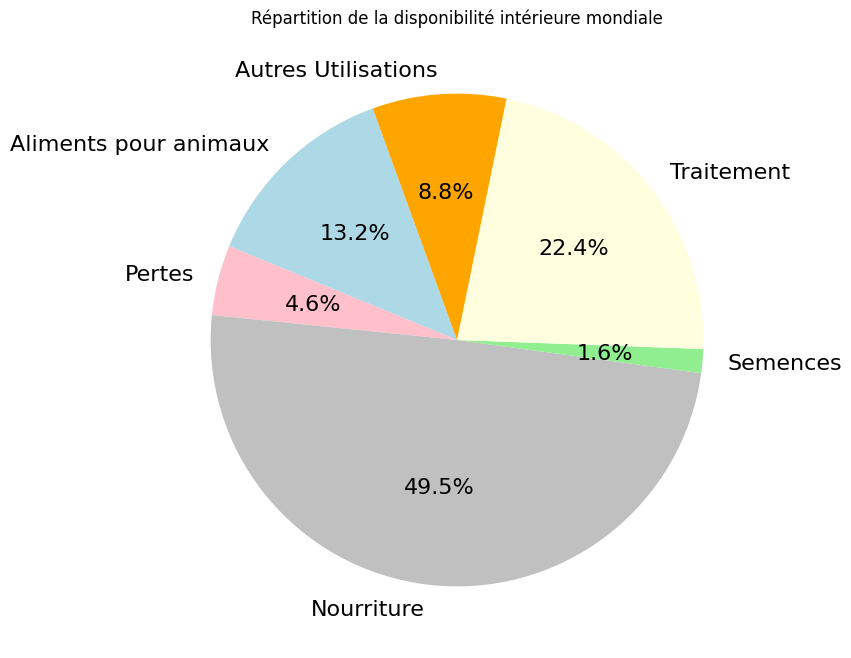

In [33]:
# Calcul et stockage des proportions dans une variable
proportions = {col: dispo_alimentaire[col].sum() * 100 / total_dispo_int for col in ["Aliments pour animaux",
                                                                                     "Pertes",
                                                                                     "Nourriture",
                                                                                     "Semences",
                                                                                     "Traitement",
                                                                                     "Autres Utilisations"]}

#Affichage des proportions
for key in proportions.keys():
    print("Proportion de:", key, "=", "{:.2f}".format(proportions[key]), "%")

#Graphique des proportions
plt.figure(figsize=(8, 8))
plt.pie(proportions.values(),
        labels=proportions.keys(),
        autopct='%1.1f%%',
        startangle=110,
        colors=["lightblue", "pink", "silver", "lightgreen", "lightyellow", "orange"],
        textprops={'fontsize': 16})
plt.title("Répartition de la disponibilité intérieure mondiale")
plt.show()

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4.3 - Filtrage sur les céréales</h4>
</div>

In [34]:
#Vérification des valeurs prises par la colonne Produit

print("Les valeurs prises par la colonne Produit dans la table dispo_alimentaire sont:")
valeur_produit = (sorted(dispo_alimentaire["Produit"].unique()))
for produit in valeur_produit:
    print(produit)

Les valeurs prises par la colonne Produit dans la table dispo_alimentaire sont:
Abats Comestible
Agrumes, Autres
Alcool, non Comestible
Aliments pour enfants
Ananas
Animaux Aquatiques Autre
Arachides Decortiquees
Avoine
Bananes
Bananes plantains
Beurre, Ghee
Bière
Blé
Boissons Alcooliques
Boissons Fermentés
Café
Cephalopodes
Citrons & Limes
Coco (Incl Coprah)
Crustacés
Crème
Céréales, Autres
Dattes
Edulcorants Autres
Feve de Cacao
Fruits, Autres
Girofles
Graines Colza/Moutarde
Graines de coton
Graines de tournesol
Graisses Animales Crue
Haricots
Huil Plantes Oleif Autr
Huile Graines de Coton
Huile d'Arachide
Huile d'Olive
Huile de Coco
Huile de Colza&Moutarde
Huile de Germe de Maïs
Huile de Palme
Huile de Palmistes
Huile de Soja
Huile de Son de Riz
Huile de Sésame
Huile de Tournesol
Huiles de Foie de Poisso
Huiles de Poissons
Ignames
Lait - Excl Beurre
Légumes, Autres
Légumineuses Autres
Manioc
Maïs
Miel
Millet
Miscellanees
Mollusques, Autres
Noix
Oeufs
Oignons
Olives
Oranges, Mandarin

In [35]:
#Création d'une liste avec toutes les variables de céréales
liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [36]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereales = dispo_alimentaire.loc[dispo_alimentaire["Produit"].isin(liste_cereales),:]

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4.5 - Répartition des céréales : alimentation humaine vs animale</h4>
</div>

In [37]:
#Affichage de la proportion d'alimentation animale
print("Proportion d'alimentation animale avec les céréales :",
      "{:.2f}".format(cereales["Aliments pour animaux"].sum()*100/cereales["Disponibilité intérieure"].sum()),
      "%")

#Affichage de la proportion d'alimentation humaine
print("Proportion d'alimentation humaine avec les céréales :",
      "{:.2f}".format(cereales["Nourriture"].sum()*100/cereales["Disponibilité intérieure"].sum()),
      "%")

Proportion d'alimentation animale avec les céréales : 36.29 %
Proportion d'alimentation humaine avec les céréales : 42.75 %


In [38]:
#Création tableau avec produits regroupés (somme)
cereales_grouped = (cereales.groupby("Produit"))[["Aliments pour animaux", "Nourriture"]].sum().reset_index()
cereales_grouped

,Produit,Aliments pour animaux,Nourriture
0,Avoine,1.625100e+10,3.903000e+09
1,Blé,1.296680e+11,4.578240e+11
2,"Céréales, Autres",1.903500e+10,5.324000e+09
3,Maïs,5.461160e+11,1.251840e+11
4,Millet,3.306000e+09,2.304000e+10
5,Orge,9.265800e+10,6.794000e+09
6,Riz (Eq Blanchi),3.359400e+10,3.772860e+11
7,Seigle,8.099000e+09,5.502000e+09
8,Sorgho,2.480800e+10,2.415300e+10


In [39]:
# Ajout des proportions pour chaque produit dans la table
cereales_grouped["Aliments pour animaux %"] = cereales_grouped["Aliments pour animaux"]*100/(cereales_grouped["Aliments pour animaux"].sum())
cereales_grouped["Nourriture %"] = cereales_grouped["Nourriture"]*100/(cereales_grouped["Nourriture"].sum())
cereales_grouped

,Produit,Aliments pour animaux,Nourriture,Aliments pour animaux %,Nourriture %
0,Avoine,1.625100e+10,3.903000e+09,1.860372,0.379297
1,Blé,1.296680e+11,4.578240e+11,14.844053,44.491696
2,"Céréales, Autres",1.903500e+10,5.324000e+09,2.179077,0.517391
3,Maïs,5.461160e+11,1.251840e+11,62.517930,12.165479
4,Millet,3.306000e+09,2.304000e+10,0.378462,2.239045
5,Orge,9.265800e+10,6.794000e+09,10.607245,0.660246
6,Riz (Eq Blanchi),3.359400e+10,3.772860e+11,3.845753,36.664950
7,Seigle,8.099000e+09,5.502000e+09,0.927152,0.534689
8,Sorgho,2.480800e+10,2.415300e+10,2.839955,2.347208


<div style="page-break-after: always;"></div>

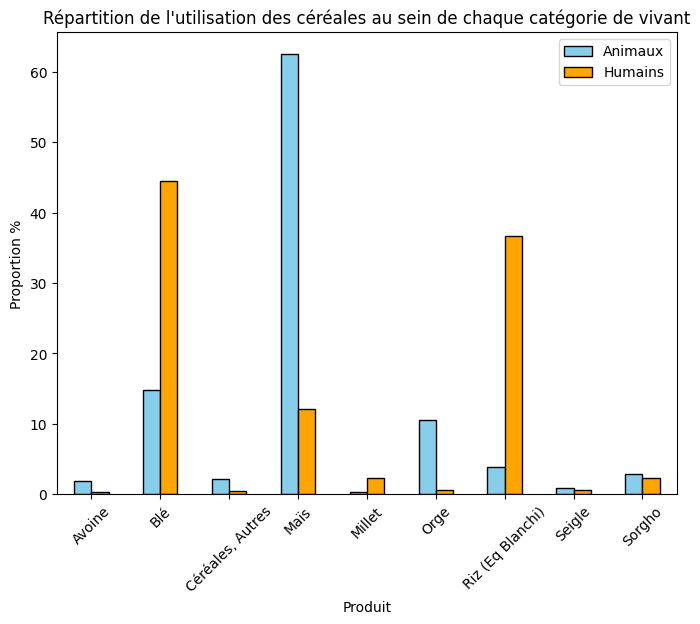

In [40]:
# Graphique représentant l'utilisation des céréales au sein de chaque catégorie de vivant: humain vs animal
cereales_grouped.sort_values(by="Produit", ascending=True).plot(kind='bar',
                                                                x="Produit",
                                                                y=["Aliments pour animaux %", "Nourriture %"],
                                                                color=["skyblue", "orange"],
                                                                figsize=(8, 6),
                                                                edgecolor="black",
                                                                label=["Animaux", "Humains"],
                                                                title="Répartition de l'utilisation des céréales au sein de chaque catégorie de vivant",
                                                                xlabel = "Produit",
                                                                ylabel = "Proportion %")
plt.xticks(rotation=45)
plt.show()

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5.1 - Ajout colonne proportion de sous-nutris %</h4>
</div>

In [41]:
#Création de la colonne proportion par pays

print("---AVANT AJOUT COLONNE PROPORTION DANS LA TABLE SS-NUTRI POP 2017---")
generate_stats(ssnutrition_pop_left_2017, "jointure sous-nutrition et population")

ssnutrition_pop_left_2017["ss-nutri(%)"] = round(((ssnutrition_pop_left_2017["sous_nutrition"]/ssnutrition_pop_left_2017["Population"])*100),2)
print("---APRES AJOUT COLONNE PROPORTION DANS LA TABLE SS-NUTRI POP 2017---")
generate_stats(ssnutrition_pop_left_2017, "avec colonne proportion")

print("---AVEC TRI DE LA COLONNE SS-NUTRI(%) PAR ORDRE DECROISSANT---")
ssnutrition_pop_left_2017_desc = ssnutrition_pop_left_2017.sort_values(by="ss-nutri(%)", ascending=False)
display(ssnutrition_pop_left_2017_desc.head(10).reset_index())



---AVANT AJOUT COLONNE PROPORTION DANS LA TABLE SS-NUTRI POP 2017---
---Infos générales sur les données du tableau: jointure sous-nutrition et population ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (203, 4)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,203.0,NaN,NaN,NaN,NaN,2017.0,0.0,2017.0,2017.0,2017.0,2017.0,2017.0
sous_nutrition,float64,0,203.0,NaN,NaN,NaN,NaN,2638916.256158,13895629.799781,0.0,0.0,0.0,1200000.0,190100000.0
Population,float64,0,203.0,NaN,NaN,NaN,NaN,37161570.339901,141582232.36789,1300.0,1439067.5,7698474.0,25500168.5,1421021791.0
Zone,object,0,203,203,Afghanistan,1,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----
---APRES AJOUT COLONNE PROPORTION DANS LA TABLE SS-NUTRI POP 2017---
---Infos générales sur les données du tableau: avec colonne proportion ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (203, 5)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,203.0,NaN,NaN,NaN,NaN,2017.0,0.0,2017.0,2017.0,2017.0,2017.0,2017.0
sous_nutrition,float64,0,203.0,NaN,NaN,NaN,NaN,2638916.256158,13895629.799781,0.0,0.0,0.0,1200000.0,190100000.0
Population,float64,0,203.0,NaN,NaN,NaN,NaN,37161570.339901,141582232.36789,1300.0,1439067.5,7698474.0,25500168.5,1421021791.0
ss-nutri(%),float64,0,203.0,NaN,NaN,NaN,NaN,5.845567,9.978504,0.0,0.0,0.0,7.525,48.26
Zone,object,0,203,203,Afghanistan,1,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----
---AVEC TRI DE LA COLONNE SS-NUTRI(%) PAR ORDRE DECROISSANT---


,index,Zone,sous_nutrition,Année,Population,ss-nutri(%)
0,78,Haïti,5300000.0,2017,10982366.0,48.26
1,157,République populaire démocratique de Corée,12000000.0,2017,25429825.0,47.19
2,108,Madagascar,10500000.0,2017,25570512.0,41.06
3,103,Libéria,1800000.0,2017,4702226.0,38.28
4,100,Lesotho,800000.0,2017,2091534.0,38.25
5,183,Tchad,5700000.0,2017,15016753.0,37.96
6,161,Rwanda,4200000.0,2017,11980961.0,35.06
7,121,Mozambique,9400000.0,2017,28649018.0,32.81
8,186,Timor-Leste,400000.0,2017,1243258.0,32.17
9,0,Afghanistan,10500000.0,2017,36296113.0,28.93


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5.2 - Rappel : moitié des pays manquants</h4>
</div>

In [42]:
print("Attention, on n'a pas les données de tous les pays:")
display(ssnutrition_pop_left_2017_desc.tail(10))

Attention, on n'a pas les données de tous les pays:


,Zone,sous_nutrition,Année,Population,ss-nutri(%)
189,Tonga,0.0,2017,101998.0,0.0
188,Tokélaou,0.0,2017,1300.0,0.0
194,Tuvalu,0.0,2017,11370.0,0.0
193,Turquie,0.0,2017,81116450.0,0.0
191,Tunisie,0.0,2017,11433443.0,0.0
196,Uruguay,0.0,2017,3436641.0,0.0
197,Vanuatu,0.0,2017,285510.0,0.0
200,Yémen,0.0,2017,27834819.0,0.0
201,Zambie,0.0,2017,16853599.0,0.0
202,Zimbabwe,0.0,2017,14236595.0,0.0


En faisant une simple recherche par exemple, on constate pour le Zimbabwé, la proportion de sous-nutris en 2017 était de 36% et de 29% pour la Zambie.
<br>Source: https://donnees.banquemondiale.org/indicateur/SN.ITK.DEFC.ZS?locations=ZW-ZM

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5.3 - Résultats</h4>
</div>

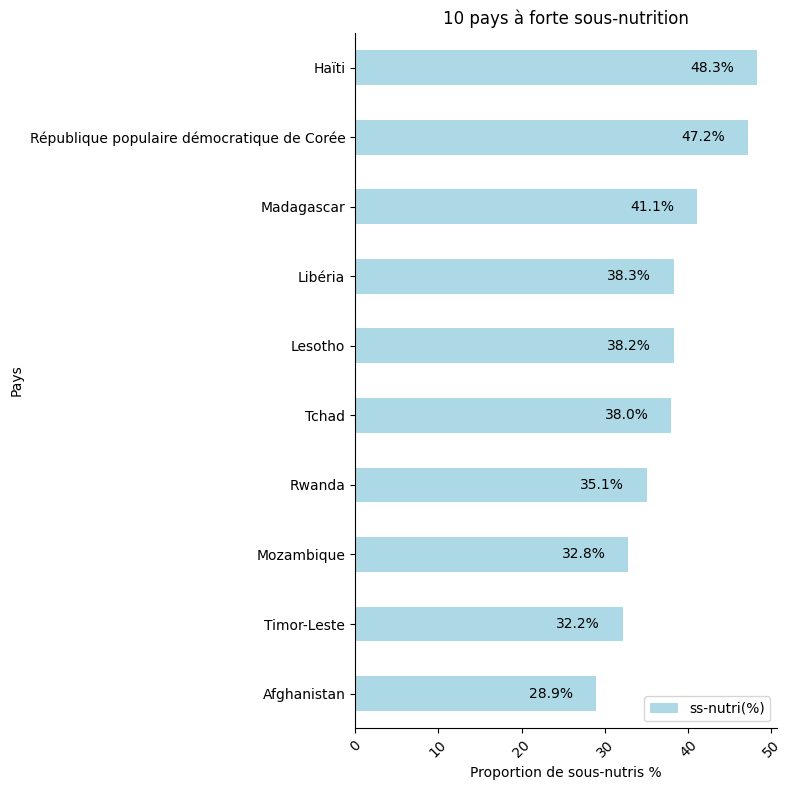

In [43]:
ssnutrition_pop_left_2017_desc.head(10).sort_values(by = "ss-nutri(%)").plot(kind='barh',
                                    x="Zone",
                                    y="ss-nutri(%)",
                                    color="lightblue",
                                    figsize=(8, 8),
                                    title="10 pays à forte sous-nutrition",
                                    ylabel = "Pays",
                                    xlabel = "Proportion de sous-nutris %")
plt.xticks(rotation=45)

# Ajouter les annotations (proportions avec %)
for index, value in enumerate((ssnutrition_pop_left_2017_desc.head(10).sort_values(by = "ss-nutri(%)"))["ss-nutri(%)"]):
    plt.text(
        value - 8,  # Position horizontale légèrement avant la barre
        index,        # Position verticale alignée avec la barre
        f"{value:.1f}%",  # Texte à afficher avec une décimale
        va="center",  # Alignement vertical
        fontsize=10,   # Taille de police
    )

plt.tight_layout()
plt.gca().spines[['top',"right"]].set_visible(False) # Enlever les bordures en haut et à droite du graphique.
plt.show()

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6.1 - Aggrégation des données</h4>
</div>

In [44]:
# Rappel infos de la table
generate_stats(aide_alimentaire, "aide alim")

---Infos générales sur les données du tableau: aide alim ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (1475, 4)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,1475.0,NaN,NaN,NaN,NaN,2014.054237,0.946916,2013.0,2013.0,2014.0,2015.0,2016.0
Valeur(kg),int64,0,1475.0,NaN,NaN,NaN,NaN,7481966.779661,23339531.424348,0.0,287500.0,1178000.0,4334500.0,265013000.0
Zone,object,0,1475,76,Algérie,39,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Produit,object,0,1475,16,Non-céréales,220,14.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


In [45]:
#Calcul du total de l'aide alimentaire par pays (regroupement par zone)
aide_alim_group_pays = aide_alimentaire.groupby("Zone")["Valeur(kg)"].sum().reset_index() # si je ne mets pas le reset_index, je n'ai pas de dataframe en sortie, c'est pourquoi il faut réaffecter des nouveaux index

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6.2 - Résultats</h4>
</div>

In [46]:
#Affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire
display(aide_alim_group_pays.sort_values(by="Valeur(kg)", ascending=False).head(10).reset_index(drop=True))

,Zone,Valeur(kg)
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000
5,Kenya,552836000
6,Bangladesh,348188000
7,Somalie,292678000
8,République démocratique du Congo,288502000
9,Niger,276344000


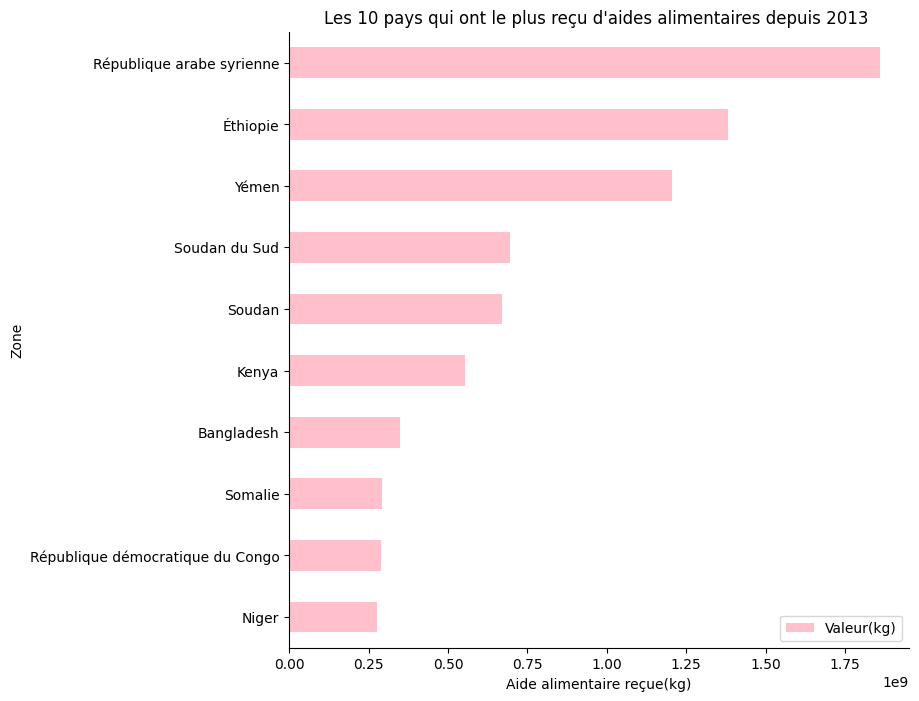

In [47]:
aide_alim_group_pays.sort_values(by="Valeur(kg)", ascending=False).head(10).sort_values(by="Valeur(kg)").plot(kind="barh",
                                                                x="Zone",
                                                                y="Valeur(kg)",
                                                                figsize=(8,8),
                                                                ylabel="Zone",
                                                                xlabel="Aide alimentaire reçue(kg)",
                                                                color="pink",
                                                                title="Les 10 pays qui ont le plus reçu d'aides alimentaires depuis 2013 ")
plt.gca().spines[["top", "right"]].set_visible(False)

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Evolution des 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7.1 - Aggrégation des données</h4>
</div>

Remarque: Les données sont déjà entre 2013 et 2016, pas de filtre à faire

In [48]:
# Groupby sur zone et année
aide_alim_group_pays_annee = aide_alimentaire.groupby(["Zone", "Année"])["Valeur(kg)"].sum().reset_index()
generate_stats(aide_alim_group_pays_annee, "aide_alim_group_pays_annee")
display(aide_alim_group_pays_annee)

---Infos générales sur les données du tableau: aide_alim_group_pays_annee ---
Dimensions du tableau (nombre de lignes, nombre de colonnes): (228, 3)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
Année,int64,0,228.0,NaN,NaN,NaN,NaN,2014.175439,1.004357,2013.0,2013.0,2014.0,2015.0,2016.0
Valeur(kg),int64,0,228.0,NaN,NaN,NaN,NaN,48403074.561404,105966549.41181,0.0,2635000.0,11757000.0,39246000.0,651870000.0
Zone,object,0,228,76,Algérie,4,1.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


,Zone,Année,Valeur(kg)
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7.2 - Filtrage</h4>
</div>

In [49]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiés de l'aide alimentaire
pays_aide_alim = list(aide_alim_group_pays.sort_values(by="Valeur(kg)", ascending=False).head(5).reset_index(drop=True)["Zone"])
print("Les 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016 sont:")
display(pays_aide_alim)

Les 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016 sont:


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [50]:
#On filtre sur le dataframe avec notre liste
aide_alim_group_pays_annee_5 = aide_alim_group_pays_annee.loc[aide_alim_group_pays_annee["Zone"].isin(pays_aide_alim)]

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7.3 - Résultat</h4>
</div>

In [51]:
# Affichage des pays avec l'aide alimentaire par année
print("Evolution de l'aide alimentaire pour les 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016")
display(aide_alim_group_pays_annee_5)

Evolution de l'aide alimentaire pour les 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016


,Zone,Année,Valeur(kg)
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


<div style="page-break-after: always;"></div>

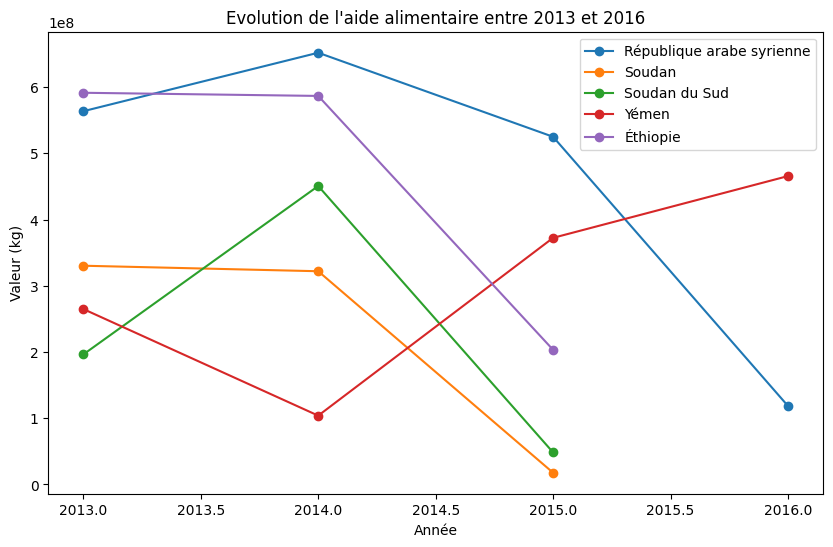

In [52]:
# Graphique

plt.figure(figsize=(10, 6))

for zone in aide_alim_group_pays_annee_5["Zone"].unique():
    subset = aide_alim_group_pays_annee_5[aide_alim_group_pays_annee_5["Zone"] == zone]  # Filtrer les données pour le pays
    plt.plot(subset["Année"], subset["Valeur(kg)"], marker="o", label=zone)

plt.legend(loc="best")
plt.ylabel("Valeur (kg)")
plt.xlabel("Année")
plt.title("Evolution de l'aide alimentaire entre 2013 et 2016")
plt.show()

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [53]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alim_group_pays = (dispo_alimentaire.groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"].sum().reset_index())

# Tri ascendant
dispo_alim_group_pays_asc = dispo_alim_group_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)")

#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
print("Pays qui ont le moins de disponibilité alimentaire par personne en kcal/jour")
display(dispo_alim_group_pays_asc.head(10).reset_index())

Pays qui ont le moins de disponibilité alimentaire par personne en kcal/jour


,index,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,128,République centrafricaine,1879.0
1,166,Zambie,1924.0
2,91,Madagascar,2056.0
3,0,Afghanistan,2087.0
4,65,Haïti,2089.0
5,133,République populaire démocratique de Corée,2093.0
6,151,Tchad,2109.0
7,167,Zimbabwe,2113.0
8,114,Ouganda,2126.0
9,172,Éthiopie,2129.0


<div style="page-break-after: always;"></div>

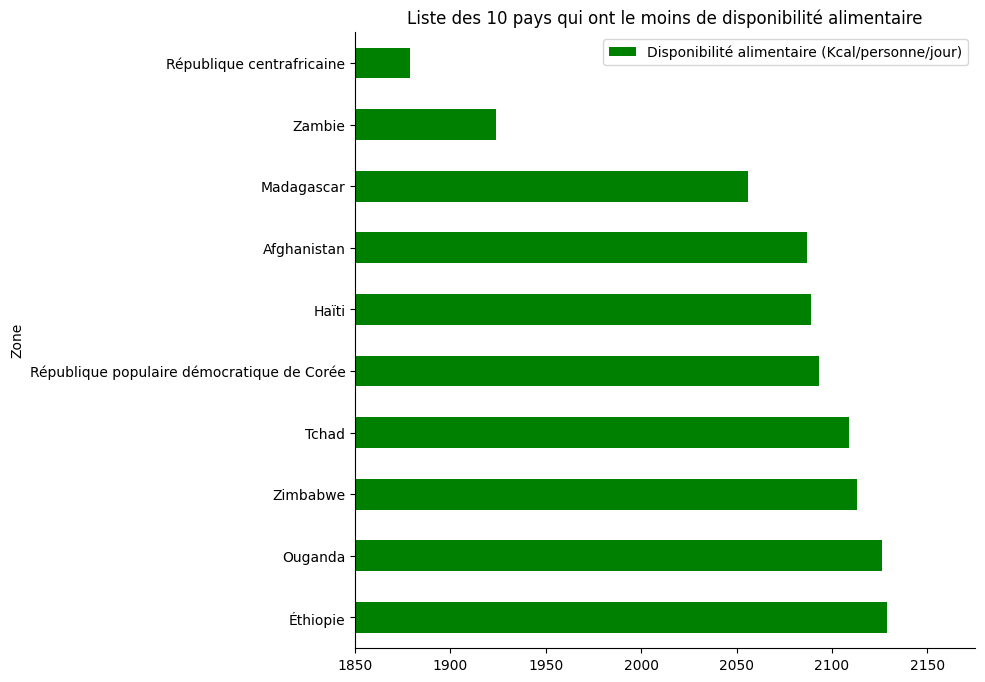

In [54]:
# Liste des 10 pays qui ont le moins de disponibilité alimentaire - sous forme graphique
dispo_alim_group_pays_asc.head(10).sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).plot(kind="barh",
                                                                                                          x="Zone",
                                                                                                          y="Disponibilité alimentaire (Kcal/personne/jour)",
                                                                                                          figsize=(8,8),
                                                                                                          color = "green",
                                                                                                          title="Liste des 10 pays qui ont le moins de disponibilité alimentaire")
plt.xlim(1850, 2175)
plt.gca().spines[["top", "right"]].set_visible(False)

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [55]:
# Tri descendant
dispo_alim_group_pays_desc = dispo_alim_group_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False)

#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
print("Pays qui ont le plus de disponibilité alimentaire par personne en kcal/jour")
display(dispo_alim_group_pays_desc.head(10).reset_index())

Pays qui ont le plus de disponibilité alimentaire par personne en kcal/jour


,index,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,11,Autriche,3770.0
1,16,Belgique,3737.0
2,159,Turquie,3708.0
3,171,États-Unis d'Amérique,3682.0
4,74,Israël,3610.0
5,72,Irlande,3602.0
6,75,Italie,3578.0
7,89,Luxembourg,3540.0
8,168,Égypte,3518.0
9,4,Allemagne,3503.0


<div style="page-break-after: always;"></div>

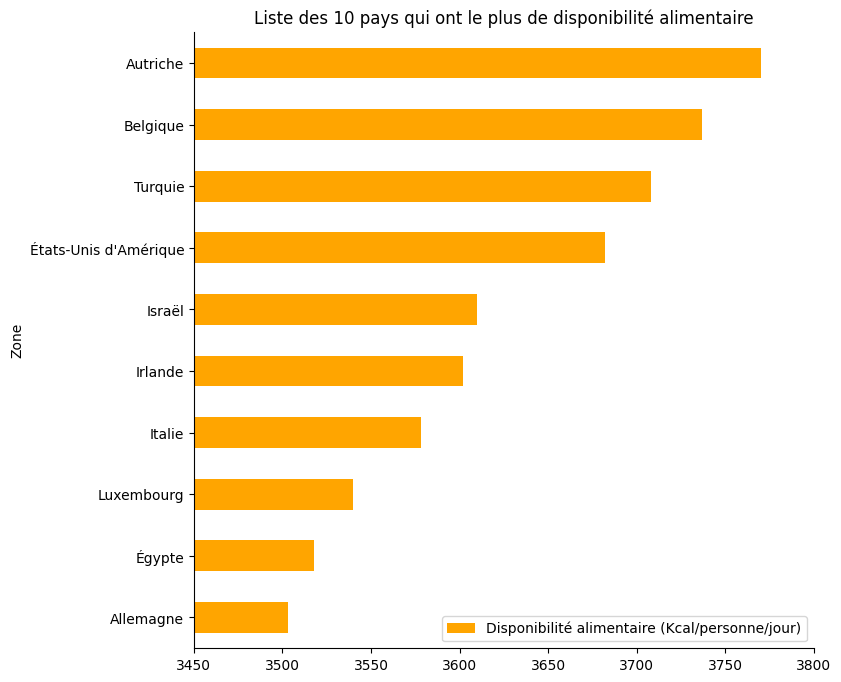

In [56]:
# Liste des 10 pays qui ont le plus de disponibilité alimentaire - sous forme graphique
dispo_alim_group_pays_desc.head(10).sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)").plot(kind="barh",
                                                                                                          x="Zone",
                                                                                                          y="Disponibilité alimentaire (Kcal/personne/jour)",
                                                                                                          figsize=(8,8),
                                                                                                          color = "orange",
                                                                                                          title="Liste des 10 pays qui ont le plus de disponibilité alimentaire")
plt.xlim(3450, 3800)
plt.gca().spines[["top", "right"]].set_visible(False)

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10.1 - Sous-nutrition : filtre sur la Thaïlande</h4>
</div>

In [57]:
#création d'un dataframe avec uniquement la Thaïlande
condition_zone = ssnutrition_pop_left_2017["Zone"] == "Thaïlande"
ss_nutri_thai_2017 = ssnutrition_pop_left_2017.loc[condition_zone]

# Part de personnes en état de sous-nutrition pour la Thaïlande
display(ss_nutri_thai_2017)

,Zone,sous_nutrition,Année,Population,ss-nutri(%)
185,Thaïlande,6200000.0,2017,69209810.0,8.96


<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10.2 - Comparaison: exportation, production et importation du manioc</h4>
</div>

In [58]:
# Tableau fusionné disponibilité alimentaire et population en 2017 : filtre sur la Thaïlande et le manioc
dispo_thai_manioc = dispoAlim_pop_left_2017.loc[(dispoAlim_pop_left_2017["Zone"]=="Thaïlande") & (dispoAlim_pop_left_2017["Produit"] == "Manioc")].reset_index(drop=True)
display(dispo_thai_manioc)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal_jour,dispo_kcal_annee
0,Thaïlande,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,0.14,6.264000e+09,...,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,2017.0,69209810.0,2.768392e+09,1.010463e+12


In [59]:
# Proportion d'exportation par rapport à la production
export_manioc_thai = dispo_thai_manioc["Exportations - Quantité"] * 100 / (dispo_thai_manioc["Production"])
print(f"La Thaïlande exporte environ {export_manioc_thai.iloc[0]:.2f} % de sa production en 2017.")

La Thaïlande exporte environ 83.41 % de sa production en 2017.


<div style="page-break-after: always;"></div>

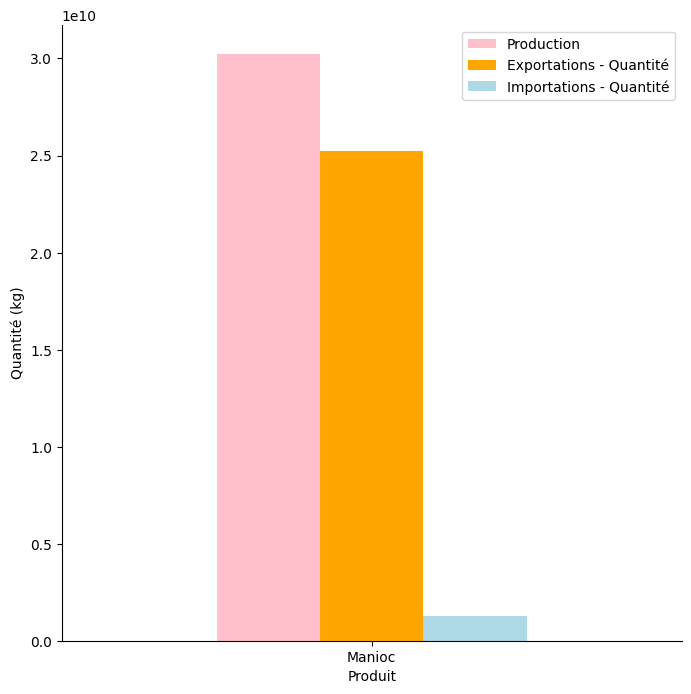

In [60]:
# Est-ce que c'est logique? (comparaison entre exportations et la production de Manioc)

dispo_thai_manioc.plot(kind = "bar",
                       x="Produit",
                       y=["Production", "Exportations - Quantité", "Importations - Quantité"],
                       color=["pink", "orange", "lightblue"],
                       figsize = (8,8),
                       ylabel = "Quantité (kg)")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.xticks(rotation = 0)
plt.show()

<div style="page-break-after: always;"></div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse complémentaires</h2>
</div>

In [61]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être
#le plus en difficulté au niveau alimentaire"

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">4.1 - Sous-nutrition au Yémen</h4>
</div>

Intéressons-nous au Yémen (qui fait partie des pays qui ont reçu le plus d'aide alimentaire).

D'après la banque mondiale, 43% de la population était en sous-nutrition en 2017.

Source: Banque Mondiale https://donnees.banquemondiale.org/indicateur/SN.ITK.DEFC.ZS?end=2017&locations=YE&start=2015

In [62]:
# Affichage du tableau joint sous-nutrition & population en 2017
ssnutrition_pop_left_2017

,Zone,sous_nutrition,Année,Population,ss-nutri(%)
0,Afghanistan,10500000.0,2017,36296113.0,28.93
1,Afrique du Sud,3100000.0,2017,57009756.0,5.44
2,Albanie,100000.0,2017,2884169.0,3.47
3,Algérie,1300000.0,2017,41389189.0,3.14
4,Allemagne,0.0,2017,82658409.0,0.00
...,...,...,...,...,...
198,Venezuela (République bolivarienne du),8000000.0,2017,29402484.0,27.21
199,Viet Nam,6500000.0,2017,94600648.0,6.87
200,Yémen,0.0,2017,27834819.0,0.00
201,Zambie,0.0,2017,16853599.0,0.00


In [63]:
# Affichage de la ligne concernant le Yémen
ssnutrition_pop_left_2017.loc[ssnutrition_pop_left_2017["Zone"]=="Yémen"]

,Zone,sous_nutrition,Année,Population,ss-nutri(%)
200,Yémen,0.0,2017,27834819.0,0.0


<div style="page-break-after: always;"></div>

In [64]:
# Stockage de la population du Yémen dans la variable pop_yemen
pop_yemen = int(population_2017.loc[(population_2017["Zone"]=="Yémen"), "Population"].iloc[0])

# Stockage du pourcentage de sous-nutris au Yémen (Source : banque mondiale)
prop_ssnutri_yemen = 43

# Ajout de la proportion de sous-nutris dans le tableau joint ss_nutrition & population en 2017
ssnutrition_pop_left_2017.loc[(ssnutrition_pop_left_2017.index == 200), ["ss-nutri(%)"]] = prop_ssnutri_yemen

# Calcul du nombre de sous-nutris à partir de la proportion et de la population
ssnutrition_pop_left_2017.loc[(ssnutrition_pop_left_2017.index == 200), ["sous_nutrition"]] = (prop_ssnutri_yemen/100)*pop_yemen

In [65]:
# Affichage du tableau joint sous-nutrition et population en 2017, mis à jour
ssnutrition_pop_left_2017

,Zone,sous_nutrition,Année,Population,ss-nutri(%)
0,Afghanistan,10500000.00,2017,36296113.0,28.93
1,Afrique du Sud,3100000.00,2017,57009756.0,5.44
2,Albanie,100000.00,2017,2884169.0,3.47
3,Algérie,1300000.00,2017,41389189.0,3.14
4,Allemagne,0.00,2017,82658409.0,0.00
...,...,...,...,...,...
198,Venezuela (République bolivarienne du),8000000.00,2017,29402484.0,27.21
199,Viet Nam,6500000.00,2017,94600648.0,6.87
200,Yémen,11968972.17,2017,27834819.0,43.00
201,Zambie,0.00,2017,16853599.0,0.00


In [66]:
# Tri du tableau joint sous-nutrition et population en 2017, par ss-nutri(%)
ssnutrition_pop_left_2017.sort_values(by="ss-nutri(%)", ascending=False).head(10).reset_index()

,index,Zone,sous_nutrition,Année,Population,ss-nutri(%)
0,78,Haïti,5300000.00,2017,10982366.0,48.26
1,157,République populaire démocratique de Corée,12000000.00,2017,25429825.0,47.19
2,200,Yémen,11968972.17,2017,27834819.0,43.00
3,108,Madagascar,10500000.00,2017,25570512.0,41.06
4,103,Libéria,1800000.00,2017,4702226.0,38.28
5,100,Lesotho,800000.00,2017,2091534.0,38.25
6,183,Tchad,5700000.00,2017,15016753.0,37.96
7,161,Rwanda,4200000.00,2017,11980961.0,35.06
8,121,Mozambique,9400000.00,2017,28649018.0,32.81
9,186,Timor-Leste,400000.00,2017,1243258.0,32.17


<div style="page-break-after: always;"></div>

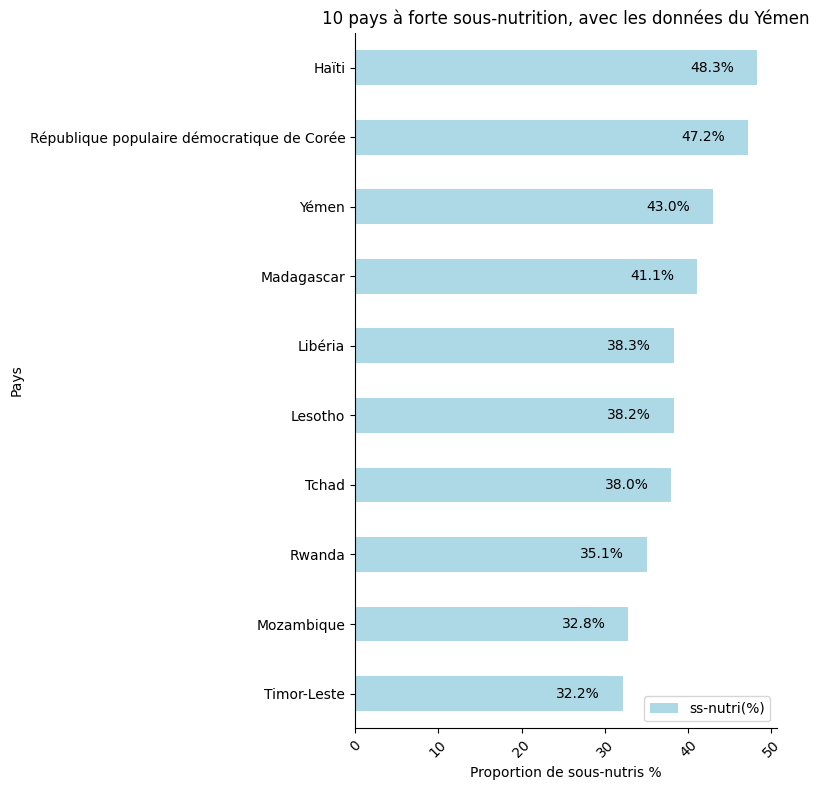

In [67]:
# Graphique avec les données à jour
ssnutrition_pop_left_2017.sort_values(by="ss-nutri(%)", ascending=False).head(10).sort_values(by = "ss-nutri(%)").plot(kind='barh',
                                    x="Zone",
                                    y="ss-nutri(%)",
                                    color="lightblue",
                                    figsize=(8, 8),
                                    title="10 pays à forte sous-nutrition, avec les données du Yémen",
                                    ylabel = "Pays",
                                    xlabel = "Proportion de sous-nutris %")
plt.xticks(rotation=45)

# Ajouter les annotations (proportions avec %)
for index, value in enumerate((ssnutrition_pop_left_2017.sort_values(by="ss-nutri(%)", ascending=False).head(10).sort_values(by = "ss-nutri(%)"))["ss-nutri(%)"]):
    plt.text(
        value - 8,  # Position horizontale légèrement avant la barre
        index,        # Position verticale alignée avec la barre
        f"{value:.1f}%",  # Texte à afficher avec une décimale
        va="center",  # Alignement vertical
        fontsize=10,   # Taille de police
    )

plt.tight_layout()
plt.gca().spines[['top',"right"]].set_visible(False) # Enlever les bordures en haut et à droite du graphique.
plt.show()

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">4.2 - Disponbilité alimentaire au Yémen : importations et exportations</h4>
</div>

In [68]:
dispo_yemen = dispo_alimentaire.loc[dispo_alimentaire["Zone"]=="Yémen"]

In [69]:
dispo_yemen.loc[dispo_yemen["Origine"]=="vegetale"].sort_values(by="Exportations - Quantité", ascending=False).head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
14793,Yémen,Blé,vegetale,0.0,0.0,884.0,110.24,5.77,26.52,2.799000e+09,170000000.0,3.186000e+09,2.691000e+09,98000000.0,232000000.0,11000000.0,0.0,-449000000.0
14838,Yémen,Oignons,vegetale,0.0,0.0,3.0,3.71,0.02,0.11,1.020000e+08,125000000.0,0.000000e+00,9.000000e+07,11000000.0,227000000.0,0.0,0.0,0.0
14806,Yémen,"Fruits, Autres",vegetale,0.0,0.0,29.0,30.42,0.11,0.29,7.660000e+08,76000000.0,3.730000e+08,7.420000e+08,24000000.0,469000000.0,0.0,0.0,0.0
14789,Yémen,Bananes,vegetale,0.0,0.0,4.0,2.66,0.02,0.05,7.000000e+07,56000000.0,0.000000e+00,6.500000e+07,5000000.0,126000000.0,0.0,0.0,0.0
14782,Yémen,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.16,0.00,0.00,-9.000000e+06,32000000.0,2.300000e+07,4.000000e+06,0.0,0.0,0.0,0.0,0.0
14828,Yémen,"Légumes, Autres",vegetale,0.0,0.0,12.0,16.61,0.10,0.45,4.240000e+08,23000000.0,7.500000e+07,4.050000e+08,19000000.0,368000000.0,0.0,0.0,4000000.0
14853,Yémen,Pommes,vegetale,0.0,0.0,2.0,2.03,0.01,0.00,5.100000e+07,16000000.0,1.800000e+07,5.000000e+07,2000000.0,20000000.0,0.0,0.0,30000000.0
14831,Yémen,Maïs,vegetale,183000000.0,0.0,118.0,13.22,1.66,3.13,5.410000e+08,9000000.0,4.750000e+08,3.230000e+08,27000000.0,75000000.0,3000000.0,6000000.0,0.0
14856,Yémen,Raisin,vegetale,0.0,0.0,11.0,5.91,0.05,0.10,1.520000e+08,5000000.0,1.000000e+06,1.440000e+08,8000000.0,156000000.0,0.0,0.0,0.0
14820,Yémen,Huile de Palme,vegetale,0.0,60000000.0,156.0,6.45,17.68,0.00,2.170000e+08,4000000.0,2.210000e+08,1.580000e+08,0.0,0.0,0.0,0.0,0.0


<div style="page-break-after: always;"></div>

Text(0.5, 1.0, 'Quantité de produits alimentaires exportés')

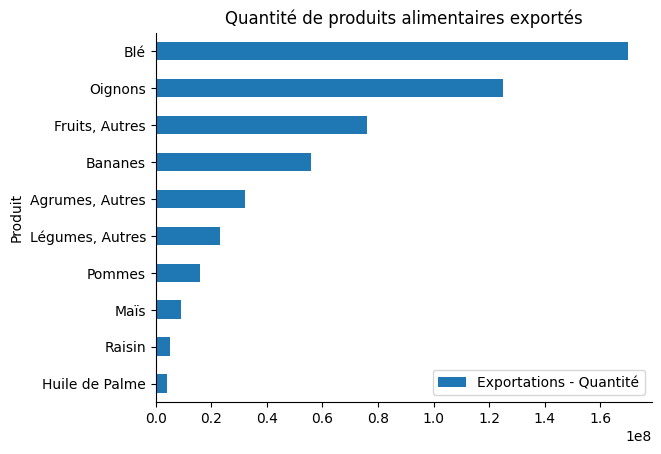

In [70]:
# Graphique avec la quantité de produits alimentaires exportés au Yémen
dispo_yemen.loc[dispo_yemen["Origine"]=="vegetale"].sort_values(by="Exportations - Quantité", ascending=False).head(10).sort_values(by="Exportations - Quantité").plot(kind="barh",
                                                                                                                                                                       x="Produit",
                                                                                                                                                                       y="Exportations - Quantité")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.title("Quantité de produits alimentaires exportés")

<div style="page-break-after: always;"></div>

In [71]:
dispo_yemen.loc[dispo_yemen["Origine"]=="animale"].sort_values(by="Exportations - Quantité", ascending=False).head(10)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
14851,Yémen,Poissons Pelagiques,animale,0.0,0.0,3.0,1.28,0.16,0.39,3.100000e+07,120000000.0,23000000.0,3.100000e+07,0.0,119000000.0,0.0,0.0,10000000.0
14827,Yémen,Lait - Excl Beurre,animale,0.0,7000000.0,55.0,43.97,2.36,4.05,1.075000e+09,41000000.0,743000000.0,1.073000e+09,15000000.0,373000000.0,0.0,0.0,0.0
14797,Yémen,Cephalopodes,animale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,9000000.0,0.0,0.000000e+00,0.0,9000000.0,0.0,0.0,0.0
14791,Yémen,"Beurre, Ghee",animale,0.0,0.0,3.0,0.13,0.30,0.00,3.000000e+06,5000000.0,1000000.0,3.000000e+06,0.0,7000000.0,0.0,0.0,0.0
14800,Yémen,Crustacés,animale,0.0,0.0,0.0,0.03,0.00,0.01,1.000000e+06,1000000.0,0.0,1.000000e+06,0.0,1000000.0,0.0,0.0,0.0
14845,Yémen,Perciform,animale,0.0,0.0,1.0,1.10,0.02,0.25,2.700000e+07,1000000.0,0.0,2.700000e+07,0.0,28000000.0,0.0,0.0,0.0
14781,Yémen,Abats Comestible,animale,0.0,0.0,6.0,1.88,0.21,0.84,4.700000e+07,0.0,1000000.0,4.600000e+07,1000000.0,46000000.0,0.0,0.0,0.0
14786,Yémen,Animaux Aquatiques Autre,animale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
14801,Yémen,Crème,animale,0.0,0.0,0.0,0.03,0.02,0.00,1.000000e+06,0.0,1000000.0,1.000000e+06,0.0,0.0,0.0,0.0,0.0
14826,Yémen,Huiles de Poissons,animale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Quantité de produits alimentaires importés')

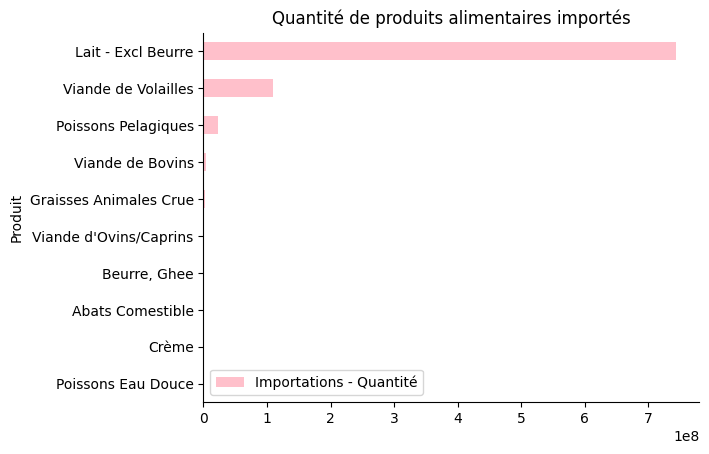

In [72]:
dispo_yemen.loc[dispo_yemen["Origine"]=="animale"].sort_values(by="Importations - Quantité", ascending=False).head(10).sort_values(by="Importations - Quantité").plot(kind="barh", x="Produit", y="Importations - Quantité", color="pink")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.title("Quantité de produits alimentaires importés")

<div style="page-break-after: always;"></div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">4.3 - Disponbilité intérieure au Yémen</h4>
</div>

In [73]:
dispo_int_yemen = int(dispo_yemen["Disponibilité intérieure"].sum())
print("La disponibilité intérieure totale au Yémen en 2017 est de :", f"{dispo_int_yemen:_}".replace("_"," "))

La disponibilité intérieure totale au Yémen en 2017 est de : 9 782 000 000


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">4.4 - Evolution de la sous-nutrition au fil du temps</h4>
</div>

ON s'intéresse aux pays qui ont reçu le plus d'aides alimentaires entre 2013 et 2016

In [74]:
sous_nutrition.loc[sous_nutrition["Zone"].isin(pays_aide_alim)]


,Zone,Année,sous_nutrition
366,Éthiopie,2012-2014,26200000.0
367,Éthiopie,2013-2015,24300000.0
368,Éthiopie,2014-2016,21700000.0
369,Éthiopie,2015-2017,21300000.0
370,Éthiopie,2016-2018,21100000.0
371,Éthiopie,2017-2019,21500000.0
900,République arabe syrienne,2012-2014,0.0
901,République arabe syrienne,2013-2015,0.0
902,République arabe syrienne,2014-2016,0.0
903,République arabe syrienne,2015-2017,0.0


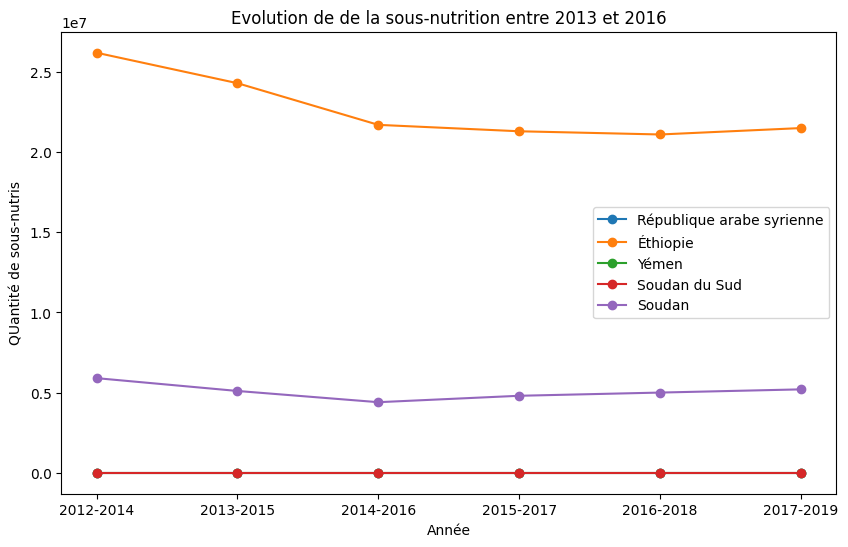

In [75]:
# Graphique d'évolution de la sous-nutrition entre 2013 et 2016
plt.figure(figsize=(10, 6))

for zone in pays_aide_alim:
    subset = sous_nutrition[sous_nutrition["Zone"] == zone]  # Filtrer les données pour le pays
    plt.plot(subset["Année"], subset["sous_nutrition"], marker="o", label=zone)

plt.legend(loc="best")
plt.ylabel("QUantité de sous-nutris")
plt.xlabel("Année")
plt.title("Evolution de de la sous-nutrition entre 2013 et 2016")
plt.show()

FIN DU NOTEBOOK - Tiphanie R.